# Token-update MLP pilot: understanding, generation, and joint training

Run the **five code cells in order** in Colab (GPU recommended). Cell 1 contains the paths and experiment settings. No Show-o2 checkpoint or new inference is needed.

- **Data:** 24 U examples (6 per named category) and 12 G examples (`counting_spatial`), conditional branch. Only the five explicitly listed folders are read; earlier pilot folders are excluded.
- **Input:** the saved decoder-layer input vector and layer ID. RMS scaling plus a separate magnitude feature preserves vector scale. No task flag, prompt ID, token type, or generation timestep is given to the MLP. Step and token type remain available for evaluation.
- **Target:** `log1p(update_l2)`; prediction is converted back to raw L2 for raw-error reporting. This avoids letting a few large chat-token scores dominate training. These are update-magnitude labels, not task-loss or pruning-safety labels.
- **Models:** identical small MLP-U, MLP-G, and MLP-UG; three training seeds. Joint minibatches are 50% U / 50% G, with uniform example sampling within each task. An epoch is 200 sampled minibatches, not a full dataset pass. All models have the same maximum update budget; validation early stopping selects the saved checkpoint.
- **Splits:** whole examples, grouping repeated image hashes/source-image URLs and repeated generation prompts. Aim for 16/4/4 U and 8/2/2 G train/validation/test; grouping takes priority over exact counts. The split stays fixed across training seeds.
- **Storage:** step 2 reads tensor metadata only, without allocating feature storage. Gzip files are streamed through a temporary file on local disk, in 1 MiB chunks; uncompressed feature files use memory mapping when read for caching. Cell 3 builds a reusable, lossless feature cache on **Colab's local disk**, one source file at a time. It keeps all recorded layers, steps, and non-padding tokens. For the stated BF16 pilot, allow roughly **35–40 GiB of local disk**; the exact requirement is printed before caching. BF16 features keep their original bits. After a previous RAM crash, restart the Colab session and run the updated cells from cell 1.
- **Evaluation:** fixed validation row samples select checkpoints; final test metrics use **all** non-padding test rows. The two primary metrics are **MSE on the original L2 scores** and **Top-K overlap = intersection / K**. Training remains in `log1p` space; log-MSE is saved only as a diagnostic. Set a Top-K fraction (default 20%) or a fixed K in cell 1. Padding is excluded before choosing K. The main scope is all valid tokens; visual-only and other token-type scopes are additional results with their own K.
- **Detail first:** compute metrics within each U sample/layer and each G sample/denoising-step/layer. Save these rows and per-example figures before any summaries. Compare U layer `l` against G at **every** `(step, l)` pair. The aligned comparison averages test examples and training seeds but never collapses the layer or step axes. It compares predictor performance, not token IDs between unrelated U/G prompts. Only token-type scopes present in both tasks are aligned.
- **Top-K ties:** use independent, reproducible random tie breaks for target and prediction, shared across models/seeds. Ambiguous cutoff ties and the trivial `K=N` case are flagged in the CSV. Random-selection expected overlap is `K/N`; tied constant targets do not define a unique important-token set. No Top-K is computed on averaged scores.
- **Summaries:** average layers/steps within each example, then give examples equal weight. Seed variation is not a confidence interval over new prompts. Evaluation files go in an `evaluation_top20pct` (or fixed-K) subfolder; changing K and rerunning only cell 5 in the same session does not retrain the models.

If the joint model matches both specialists **and beats the training-only layer-mean baselines**, the pilot supports a shared predictor of these L2 labels. A worse joint model identifies a training tradeoff under this setup; it does not prove different intrinsic importance functions. Even without a task flag, hidden states may reveal the task.

The loader uses restricted [PyTorch tensor loading](https://docs.pytorch.org/docs/stable/generated/torch.load.html) and [metadata-only checkpoint inspection](https://docs.pytorch.org/docs/stable/notes/serialization.html#layout-control). The split uses [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html). Colab normally includes the required PyTorch, NumPy, pandas, SciPy, scikit-learn, and matplotlib packages.

**Selection budget vs overlap:** with 100 valid tokens and `TOP_K_FRACTION=0.20`, each ranking selects 20 tokens. If 16 are shared, overlap is **80%**. Selecting 80% of the tokens would make random overlap already average 80%; it does not set a desired prediction accuracy.


In [ ]:
# --- 1. Configuration ---
import gc, gzip, hashlib, json, random, re, shutil, sys, tempfile, time
from contextlib import ExitStack
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch._subclasses.fake_tensor import FakeTensorMode
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from IPython.display import display

if Path("/content").is_dir():
    from google.colab import drive
    drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/intership")
CACHE_ROOT = Path("/content/token_mlp_cache")  # Local disk; not Google Drive.
OUTPUT_DIR = DATA_ROOT / "token_mlp_results" / time.strftime("pilot_%Y%m%d_%H%M%S")
U_CATEGORIES = ["counting", "spatial_relations", "visual_state_traffic_lights", "attribute_combinations"]
FOLDERS = {f"U/{name}": DATA_ROOT / "token_importance_understanding" / name for name in U_CATEGORIES}
FOLDERS["G/counting_spatial"] = DATA_ROOT / "token_importance_generation" / "counting_spatial"
EXPECTED_COUNTS = {key: (6 if key.startswith("U/") else 12) for key in FOLDERS}
BRANCH = "conditional"
SPLIT_SEED, TRAIN_SEEDS = 42, [42, 43, 44]
HIDDEN_WIDTH, BATCH_SIZE = 128, 256  # This is the MLP minibatch, not Show-o2's batch_size.
MAX_EPOCHS, UPDATES_PER_EPOCH, PATIENCE = 25, 200, 5
LEARNING_RATE, WEIGHT_DECAY = 1e-3, 1e-4
VAL_ROWS_PER_EXAMPLE, EVAL_BATCH_SIZE = 8192, 4096
TOP_K_FRACTION, TOP_K_COUNT = 0.20, None  # Select 20% of tokens; overlap is measured. COUNT overrides FRACTION.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def save_json(path, value):
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False), encoding="utf-8")

def load_pt(path, metadata_only=False):
    path = Path(path)
    with ExitStack() as stack:
        if metadata_only:
            stack.enter_context(FakeTensorMode())  # Shapes/dtypes only; no feature storage allocated.
        if path.suffix == ".gz":
            CACHE_ROOT.mkdir(parents=True, exist_ok=True)
            stream = stack.enter_context(tempfile.TemporaryFile(dir=CACHE_ROOT))
            with gzip.open(path, "rb") as compressed:
                shutil.copyfileobj(compressed, stream, length=1024 * 1024)
            stream.seek(0)
            return torch.load(stream, map_location="cpu", weights_only=True)
        return torch.load(path, map_location="cpu", weights_only=True, mmap=not metadata_only)

def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True).encode()).hexdigest()

assert BATCH_SIZE > 1 and BATCH_SIZE % 2 == 0
assert MAX_EPOCHS > 0 and UPDATES_PER_EPOCH > 0 and PATIENCE > 0
print("Device:", DEVICE, "| Results:", OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda | Results: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746


In [ ]:
# --- 2. Find the 36 examples and split by complete example groups ---
def discover_examples():
    examples, model_signatures = [], set()
    for category, folder in FOLDERS.items():
        paths = sorted(p for p in folder.glob("sample_*.pt") if re.fullmatch(r"sample_\d+\.pt", p.name))
        if len(paths) != EXPECTED_COUNTS[category]:
            raise ValueError(f"{folder}: expected {EXPECTED_COUNTS[category]} samples, found {len(paths)}")
        run_path = folder / "run.json"
        run = json.loads(run_path.read_text(encoding="utf-8"))
        if run.get("status") != "complete":
            raise ValueError(f"Incomplete collection: {run_path}")
        backbone = run.get("backbone_config", {})
        signature = {"hidden_size": backbone.get("hidden_size"), "num_decoder_layers": backbone.get("num_hidden_layers"),
                     "model_config": run.get("model_config")}
        if any(value is None for value in signature.values()):
            raise ValueError(f"Missing model metadata: {run_path}")
        model_signatures.add(digest(signature))
        for path in paths:
            print(f"Inspecting {category}/{path.stem} (metadata only)", flush=True)
            data = load_pt(path, metadata_only=True)
            task = category[0]
            sample = data["sample"]
            if data.get("score_name") != "token_decoder_update_l2_v2" or data.get("schema_version") != (2 if task == "U" else 3):
                raise ValueError(f"Unsupported token-score schema: {path}")
            if sample.get("task") != ("understanding" if task == "U" else "generation"):
                raise ValueError(f"Task mismatch: {path}")
            if not sample.get("image_sha256"):
                raise ValueError(f"Missing image hash needed for grouped splitting: {path}")
            layers = list(map(int, data["layer_indices"]))
            if not layers or layers != sorted(set(layers)):
                raise ValueError(f"Invalid layer indices: {path}")
            tokens = data["tokens"] if task == "U" else data["branches"][BRANCH]["tokens"]
            positions = [i for i, token in enumerate(tokens) if token["token_type"] != "padding"]
            if [t["sequence_position"] for t in tokens] != list(range(len(tokens))) or not positions:
                raise ValueError(f"Invalid token positions: {path}")
            steps = [-1] if task == "U" else list(map(int, data["step_indices"]))
            times = [None] if task == "U" else list(map(float, data["denoising_timesteps"]))
            if len(steps) != len(times) or steps != sorted(set(steps)) or not steps:
                raise ValueError(f"Invalid recorded steps: {path}")
            if task == "U":
                files = [path]
                feature = data["layers"][str(layers[0])].get("input_features")
                if feature is None:
                    raise ValueError(f"Missing input_features: {path}")
            else:
                files = []
                for step in steps:
                    stem = f"sample_{sample['record_index']:06d}_step_{step:04d}_{BRANCH}.pt"
                    matches = [p for p in (folder / (stem + ".gz"), folder / stem) if p.is_file()]
                    if len(matches) != 1:
                        raise ValueError(f"Expected exactly one .pt or .pt.gz for {stem}; found {len(matches)}")
                    files.append(matches[0])
                first_step = load_pt(files[0], metadata_only=True)
                feature = first_step["layers"][str(layers[0])].get("input_features")
                if feature is None:
                    raise ValueError(f"{files[0]} has scores only; input_features are required for this MLP")
            if feature.ndim != 2 or feature.shape != (len(tokens), signature["hidden_size"]) or feature.dtype not in (torch.bfloat16, torch.float16, torch.float32):
                raise ValueError(f"Unexpected input feature shape: {path}")
            codec = "bfloat16" if feature.dtype == torch.bfloat16 else "float32"
            uid = f"{category}/{path.stem}"
            examples.append(dict(uid=uid, task=task, category=category, aggregate=str(path),
                image_hash=sample["image_sha256"], source_record=sample["source_record"],
                sample_id=sample["sample_id"], run_id=data["run_id"], record_index=sample["record_index"],
                layers=layers, steps=steps, times=times, positions=positions,
                token_types=[tokens[i]["token_type"] for i in positions], tokens=tokens,
                files=list(map(str, files)), dim=int(feature.shape[1]), codec=codec,
                rows=len(positions) * len(layers) * len(steps)))
            del data, feature
            if task == "G":
                del first_step
            gc.collect()
    if len(model_signatures) != 1 or len({tuple(e["layers"]) for e in examples}) != 1:
        raise ValueError("All five folders must use the same model configuration and recorded layers")
    return examples

def split_examples(examples):
    # Link repeated images, repeated G prompts, and any matching U/G image hashes.
    parents, seen = list(range(len(examples))), {}
    def root(i):
        while parents[i] != i:
            i = parents[i]
        return i
    for i, example in enumerate(examples):
        keys = ["image:" + example["image_hash"]]
        if example["source_record"].get("source_url"):
            keys.append("source_image:" + example["source_record"]["source_url"])
        if example["task"] == "G":
            prompt = " ".join(example["source_record"]["prompt"].casefold().split())
            keys.append("prompt:" + prompt)
        for key in keys:
            if key in seen:
                parents[root(i)] = root(seen[key])
            seen[key] = i
    groups = np.array([root(i) for i in range(len(examples))])
    labels = np.array([e["category"] for e in examples])
    # Randomize group tie order; let the splitter preserve category balance.
    split_groups = np.random.default_rng(SPLIT_SEED).permutation(len(examples))[groups]
    splitter = StratifiedGroupKFold(n_splits=6, shuffle=False)
    for fold, (_, held_out) in enumerate(splitter.split(np.zeros(len(examples)), labels, split_groups)):
        for i in held_out:
            examples[i].update(group=int(groups[i]), split="test" if fold == 0 else "val" if fold == 1 else "train")
    table = pd.DataFrame([{k: e[k] for k in ("uid", "task", "category", "group", "split", "image_hash")} for e in examples])
    if table.groupby("group")["split"].nunique().max() != 1:
        raise AssertionError("An example group crossed splits")
    counts = pd.crosstab(table.category, table.split).reindex(columns=["train", "val", "test"], fill_value=0)
    if (counts == 0).any().any():
        raise ValueError(f"Grouped split left an empty category/split. Inspect repeated images/prompts.\n{counts}")
    return table, counts

examples = discover_examples()
split_table, split_counts = split_examples(examples)
LAYER_IDS, FEATURE_DIM = examples[0]["layers"], examples[0]["dim"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
split_table.to_csv(OUTPUT_DIR / "splits.csv", index=False)
display(split_counts)
print("Rows:", {task: sum(e["rows"] for e in examples if e["task"] == task) for task in ("U", "G")})
print("All layers/steps of each example stay in its displayed split.")


Inspecting U/counting/sample_000000 (metadata only)
Inspecting U/counting/sample_000001 (metadata only)
Inspecting U/counting/sample_000002 (metadata only)
Inspecting U/counting/sample_000003 (metadata only)
Inspecting U/counting/sample_000004 (metadata only)
Inspecting U/counting/sample_000005 (metadata only)
Inspecting U/spatial_relations/sample_000000 (metadata only)
Inspecting U/spatial_relations/sample_000001 (metadata only)
Inspecting U/spatial_relations/sample_000002 (metadata only)
Inspecting U/spatial_relations/sample_000003 (metadata only)
Inspecting U/spatial_relations/sample_000004 (metadata only)
Inspecting U/spatial_relations/sample_000005 (metadata only)
Inspecting U/visual_state_traffic_lights/sample_000000 (metadata only)
Inspecting U/visual_state_traffic_lights/sample_000001 (metadata only)
Inspecting U/visual_state_traffic_lights/sample_000002 (metadata only)
Inspecting U/visual_state_traffic_lights/sample_000003 (metadata only)
Inspecting U/visual_state_traffic_ligh

split,train,val,test
category,,,
G/counting_spatial,8,2,2
U/attribute_combinations,4,1,1
U/counting,4,1,1
U/spatial_relations,4,1,1
U/visual_state_traffic_lights,4,1,1


Rows: {'U': 511140, 'G': 12171012}
All layers/steps of each example stay in its displayed split.


In [ ]:
# --- 3. Read features once; keep the complete dataset on local disk ---
def cache_location(example):
    paths = [Path(example["aggregate"])] + [Path(p) for p in example["files"]]
    stats = [(str(p), p.stat().st_size, p.stat().st_mtime_ns) for p in paths]
    fingerprint = digest({"cache_version": 1, "uid": example["uid"], "sources": stats,
                          "layers": example["layers"], "positions": example["positions"], "codec": example["codec"]})
    return CACHE_ROOT / fingerprint

def cache_one(example):
    directory = cache_location(example)
    dtype = np.uint16 if example["codec"] == "bfloat16" else np.float32
    expected_sizes = {"features.bin": example["rows"] * example["dim"] * np.dtype(dtype).itemsize,
                      "labels.bin": example["rows"] * 4}
    ready = directory / "ready.json"
    if ready.exists():
        if any(not (directory / name).is_file() or (directory / name).stat().st_size != size for name, size in expected_sizes.items()):
            raise ValueError(f"Incomplete cache: {directory}. Select a fresh CACHE_ROOT.")
        return directory
    directory.mkdir(parents=True, exist_ok=True)
    cursor, positions = 0, torch.tensor(example["positions"], dtype=torch.long)
    with (directory / "features.bin").open("wb") as xf, (directory / "labels.bin").open("wb") as yf:
        for file_index, source in enumerate(example["files"]):
            payload = load_pt(Path(source))
            sample = payload["sample"]
            if payload.get("score_name") != "token_decoder_update_l2_v2" or payload["layer_indices"] != example["layers"]:
                raise ValueError(f"Score/layer mismatch: {source}")
            if sample["sample_id"] != example["sample_id"] or payload["run_id"] != example["run_id"]:
                raise ValueError(f"Sample identity mismatch: {source}")
            if payload["tokens"] != example["tokens"]:
                raise ValueError(f"Token layout changed across steps: {source}")
            if example["task"] == "G":
                valid = torch.tensor([t["token_type"] != "padding" for t in payload["tokens"]])
                if not torch.equal(payload["valid_token_mask"], valid):
                    raise ValueError(f"Invalid padding mask: {source}")
                if sample["cfg_branch"] != BRANCH or sample["step_index"] != example["steps"][file_index] or not np.isclose(sample["denoising_timestep"], example["times"][file_index]):
                    raise ValueError(f"Generation step/branch mismatch: {source}")
            for layer_offset, layer in enumerate(example["layers"]):
                values = payload["layers"][str(layer)]
                if "input_features" not in values:
                    raise ValueError(f"Missing input_features: {source}, layer {layer}")
                x, y = values["input_features"], values["update_l2"]
                if x.shape != (len(example["tokens"]), example["dim"]) or y.shape != (len(example["tokens"]),):
                    raise ValueError(f"Misaligned feature/label rows: {source}, layer {layer}")
                if not torch.equal(y, payload["update_l2_matrix"][layer_offset]):
                    raise ValueError(f"Stored label matrix mismatch: {source}, layer {layer}")
                x, y = x.index_select(0, positions).contiguous(), y.index_select(0, positions).float()
                if not torch.isfinite(x).all() or not torch.isfinite(y).all() or (y < 0).any():
                    raise ValueError(f"Nonfinite features or invalid labels: {source}, layer {layer}")
                if example["codec"] == "bfloat16":
                    if x.dtype != torch.bfloat16:
                        raise ValueError(f"Feature dtype changed: {source}")
                    x.view(torch.uint16).numpy().tofile(xf)
                else:
                    x.float().numpy().tofile(xf)
                y.numpy().tofile(yf)
                cursor += len(y)
            del payload
    if cursor != example["rows"]:
        raise ValueError(f"Wrong number of cache rows for {example['uid']}")
    save_json(ready, {"uid": example["uid"], "rows": cursor, "codec": example["codec"], "sizes": expected_sizes})
    return directory

class ExampleRows:
    def __init__(self, example, directory):
        self.info = example
        self.n_tokens, self.n_layers = len(example["positions"]), len(example["layers"])
        dtype = np.uint16 if example["codec"] == "bfloat16" else np.float32
        self.x = np.memmap(directory / "features.bin", mode="r", dtype=dtype, shape=(example["rows"], example["dim"]))
        self.y = np.memmap(directory / "labels.bin", mode="r", dtype=np.float32, shape=(example["rows"],))
    def read(self, indices):
        x = torch.from_numpy(np.array(self.x[indices], copy=True))
        if self.info["codec"] == "bfloat16":
            x = x.view(torch.bfloat16)
        layer = (np.asarray(indices) // self.n_tokens) % self.n_layers
        return x.float(), torch.as_tensor(layer, dtype=torch.long), torch.from_numpy(np.array(self.y[indices], copy=True))

needed = sum(e["rows"] * (e["dim"] * (2 if e["codec"] == "bfloat16" else 4) + 4)
             for e in examples if not (cache_location(e) / "ready.json").exists())
free = shutil.disk_usage(CACHE_ROOT).free
print(f"New local cache: {needed / 2**30:.2f} GiB | Free local disk: {free / 2**30:.2f} GiB")
if needed + 2**30 > free:
    raise OSError("Not enough local disk. Set CACHE_ROOT to a larger disk; the original Drive data stay unchanged.")
datasets = []
for example in examples:
    directory = cache_one(example)
    datasets.append(ExampleRows(example, directory))
    print(f"Cached {len(datasets)}/{len(examples)}: {example['uid']}", flush=True)

settings = {key: globals()[key] for key in ["BRANCH", "SPLIT_SEED", "TRAIN_SEEDS", "HIDDEN_WIDTH", "BATCH_SIZE",
    "MAX_EPOCHS", "UPDATES_PER_EPOCH", "PATIENCE", "LEARNING_RATE", "WEIGHT_DECAY", "VAL_ROWS_PER_EXAMPLE", "EVAL_BATCH_SIZE"]}
settings.update(feature_dim=FEATURE_DIM, layer_ids=LAYER_IDS, data_root=str(DATA_ROOT), cache_root=str(CACHE_ROOT),
    target="log1p(update_l2)", input="h/RMS(h), log1p(RMS(h)), one_hot(layer); no task or timestep",
    task_balance="UG 50/50; uniform examples within task; uniform valid rows within example",
    test_scope="all valid tokens, all recorded layers/steps", versions={"torch": str(torch.__version__), "numpy": np.__version__})
save_json(OUTPUT_DIR / "experiment.json", settings)
save_json(OUTPUT_DIR / "sources.json", examples)


New local cache: 36.33 GiB | Free local disk: 62.85 GiB
Cached 1/36: U/counting/sample_000000
Cached 2/36: U/counting/sample_000001
Cached 3/36: U/counting/sample_000002
Cached 4/36: U/counting/sample_000003
Cached 5/36: U/counting/sample_000004
Cached 6/36: U/counting/sample_000005
Cached 7/36: U/spatial_relations/sample_000000
Cached 8/36: U/spatial_relations/sample_000001
Cached 9/36: U/spatial_relations/sample_000002
Cached 10/36: U/spatial_relations/sample_000003
Cached 11/36: U/spatial_relations/sample_000004
Cached 12/36: U/spatial_relations/sample_000005
Cached 13/36: U/visual_state_traffic_lights/sample_000000
Cached 14/36: U/visual_state_traffic_lights/sample_000001
Cached 15/36: U/visual_state_traffic_lights/sample_000002
Cached 16/36: U/visual_state_traffic_lights/sample_000003
Cached 17/36: U/visual_state_traffic_lights/sample_000004
Cached 18/36: U/visual_state_traffic_lights/sample_000005
Cached 19/36: U/attribute_combinations/sample_000000
Cached 20/36: U/attribute_comb

In [ ]:
# --- 4. Train MLP-U, MLP-G, and MLP-UG; select checkpoints on validation only ---
class TokenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(FEATURE_DIM + 1 + len(LAYER_IDS), HIDDEN_WIDTH), nn.GELU(), nn.Linear(HIDDEN_WIDTH, 1))
    def forward(self, h, layer):
        rms = h.square().mean(dim=1, keepdim=True).sqrt().clamp_min(1e-6)
        layer_code = nn.functional.one_hot(layer, len(LAYER_IDS)).float()
        features = torch.cat([h / rms, torch.log1p(rms), layer_code], dim=1)
        return self.net(features).squeeze(1)  # Predict log1p(L2).

MODELS = {"MLP-U": ("U",), "MLP-G": ("G",), "MLP-UG": ("U", "G")}
train_pool = {task: [d for d in datasets if d.info["split"] == "train" and d.info["task"] == task] for task in ("U", "G")}
val_pool = {task: [d for d in datasets if d.info["split"] == "val" and d.info["task"] == task] for task in ("U", "G")}

def training_batch(tasks, rng):
    chunks = []
    for task in tasks:
        choices = rng.integers(len(train_pool[task]), size=BATCH_SIZE // len(tasks))
        for example_index in np.unique(choices):
            dataset = train_pool[task][example_index]
            indices = rng.integers(dataset.info["rows"], size=int((choices == example_index).sum()))
            chunks.append(dataset.read(indices))
    return tuple(torch.cat([chunk[i] for chunk in chunks]).to(DEVICE) for i in range(3))

validation_rows = {}
for task in ("U", "G"):
    for dataset in val_pool[task]:
        rng = np.random.default_rng(int(digest([SPLIT_SEED, dataset.info["uid"]])[:8], 16))
        indices = rng.choice(dataset.info["rows"], min(VAL_ROWS_PER_EXAMPLE, dataset.info["rows"]), replace=False)
        validation_rows[dataset.info["uid"]] = dataset.read(indices)

@torch.inference_mode()
def validation_loss(model, tasks):
    model.eval()
    task_losses = []
    for task in tasks:
        losses = []
        for dataset in val_pool[task]:
            x, layer, y = validation_rows[dataset.info["uid"]]
            squared_error = 0.0
            for start in range(0, len(y), EVAL_BATCH_SIZE):
                prediction = model(x[start:start + EVAL_BATCH_SIZE].to(DEVICE), layer[start:start + EVAL_BATCH_SIZE].to(DEVICE))
                squared_error += (prediction.cpu() - torch.log1p(y[start:start + EVAL_BATCH_SIZE])).square().sum().item()
            losses.append(squared_error / len(y))
        task_losses.append(np.mean(losses))
    return float(np.mean(task_losses))

history = []
for seed in TRAIN_SEEDS:
    for name, tasks in MODELS.items():
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        model = TokenMLP().to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        rng = np.random.default_rng(seed)
        best_loss, stale, best_state = float("inf"), 0, None
        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            train_loss = 0.0
            for _ in range(UPDATES_PER_EPOCH):
                x, layer, y = training_batch(tasks, rng)
                loss = nn.functional.mse_loss(model(x, layer), torch.log1p(y))
                if not torch.isfinite(loss):
                    raise FloatingPointError(f"Nonfinite training loss: {name}, seed {seed}")
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
            val = validation_loss(model, tasks)
            if not np.isfinite(val):
                raise FloatingPointError("Nonfinite validation loss")
            improved = val < best_loss - 1e-6
            if improved:
                best_loss, stale, best_epoch = val, 0, epoch
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
                torch.save({"state_dict": best_state, "model": name, "seed": seed, "epoch": epoch,
                    "validation_log_mse": val, "settings": settings}, OUTPUT_DIR / f"{name}_seed_{seed}.pt")
            else:
                stale += 1
            history.append(dict(model=name, seed=seed, epoch=epoch, train_log_mse=train_loss / UPDATES_PER_EPOCH, val_log_mse=val))
            print(f"{name} seed={seed} epoch={epoch:02d}: train={train_loss / UPDATES_PER_EPOCH:.4f}, val={val:.4f}", flush=True)
            if stale >= PATIENCE:
                break
        print(f"Saved {name}, seed {seed}: best epoch {best_epoch}, validation log-MSE {best_loss:.4f}")
pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)


MLP-U seed=42 epoch=01: train=0.2206, val=0.0351
MLP-U seed=42 epoch=02: train=0.0240, val=0.0266
MLP-U seed=42 epoch=03: train=0.0170, val=0.0207
MLP-U seed=42 epoch=04: train=0.0148, val=0.0171
MLP-U seed=42 epoch=05: train=0.0151, val=0.0209
MLP-U seed=42 epoch=06: train=0.0155, val=0.0163
MLP-U seed=42 epoch=07: train=0.0100, val=0.0176
MLP-U seed=42 epoch=08: train=0.0110, val=0.0149
MLP-U seed=42 epoch=09: train=0.0117, val=0.0149
MLP-U seed=42 epoch=10: train=0.0086, val=0.0163
MLP-U seed=42 epoch=11: train=0.0083, val=0.0132
MLP-U seed=42 epoch=12: train=0.0101, val=0.0141
MLP-U seed=42 epoch=13: train=0.0085, val=0.0144
MLP-U seed=42 epoch=14: train=0.0079, val=0.0114
MLP-U seed=42 epoch=15: train=0.0086, val=0.0117
MLP-U seed=42 epoch=16: train=0.0080, val=0.0148
MLP-U seed=42 epoch=17: train=0.0081, val=0.0125
MLP-U seed=42 epoch=18: train=0.0080, val=0.0144
MLP-U seed=42 epoch=19: train=0.0120, val=0.0115
Saved MLP-U, seed 42: best epoch 14, validation log-MSE 0.0114
MLP-G 

Selection budget: top20pct. Overlap is the measured agreement, not this budget.
Evaluated MLP-U, seed 42, on all U/G test tokens
Evaluated MLP-U, seed 43, on all U/G test tokens
Evaluated MLP-U, seed 44, on all U/G test tokens
Evaluated MLP-G, seed 42, on all U/G test tokens
Evaluated MLP-G, seed 43, on all U/G test tokens
Evaluated MLP-G, seed 44, on all U/G test tokens
Evaluated MLP-UG, seed 42, on all U/G test tokens
Evaluated MLP-UG, seed 43, on all U/G test tokens
Evaluated MLP-UG, seed 44, on all U/G test tokens
U: 9408 detailed rows saved; preview (no layer/step averaging):


,model,seed,uid,task,category,scope,layer,step,timestep,n_tokens,mse,log_mse,topk_overlap,k,chance_overlap,full_selection,target_cutoff_tied,prediction_cutoff_tied
155820,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,0,-1,NaN,770,47.8776,0.0275,0.4610,154,0.2,False,False,False
155827,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,1,-1,NaN,770,62.7351,0.0119,0.5909,154,0.2,False,False,False
155834,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,2,-1,NaN,770,28904.3224,0.0111,0.5714,154,0.2,False,False,False
155841,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,3,-1,NaN,770,37.4271,0.0101,0.4870,154,0.2,False,False,False
155848,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,4,-1,NaN,770,14.7770,0.0088,0.4870,154,0.2,False,False,False
155855,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,5,-1,NaN,770,17.8213,0.0100,0.4610,154,0.2,False,False,False
155862,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,6,-1,NaN,770,4.6574,0.0075,0.5455,154,0.2,False,False,False
155869,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,7,-1,NaN,770,5.2617,0.0067,0.6234,154,0.2,False,False,False
155876,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,8,-1,NaN,770,7.2683,0.0098,0.5195,154,0.2,False,False,False
155883,MLP-UG,42,U/attribute_combinations/sample_000005,U,U/attribute_combinations,all,9,-1,NaN,770,6.7568,0.0092,0.5325,154,0.2,False,False,False


G: 197568 detailed rows saved; preview (no layer/step averaging):


,model,seed,uid,task,category,scope,layer,step,timestep,n_tokens,mse,log_mse,topk_overlap,k,chance_overlap,full_selection,target_cutoff_tied,prediction_cutoff_tied
156016,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,0,0.0000,739,2.0269,0.0044,0.3176,148,0.2003,False,False,False
156184,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,1,0.0204,739,2.0817,0.0047,0.2770,148,0.2003,False,False,False
156352,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,2,0.0408,739,2.0985,0.0047,0.2973,148,0.2003,False,False,False
156520,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,3,0.0612,739,2.0635,0.0046,0.2905,148,0.2003,False,False,False
156688,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,4,0.0816,739,1.9979,0.0042,0.2905,148,0.2003,False,False,False
156856,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,5,0.1020,739,1.9564,0.0040,0.2635,148,0.2003,False,False,False
157024,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,6,0.1224,739,1.9379,0.0039,0.3041,148,0.2003,False,False,False
157192,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,7,0.1429,739,1.9562,0.0040,0.3311,148,0.2003,False,False,False
157360,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,8,0.1633,739,1.9693,0.0041,0.3243,148,0.2003,False,False,False
157528,MLP-UG,42,G/counting_spatial/sample_000000,G,G/counting_spatial,all,0,9,0.1837,739,1.9759,0.0041,0.3041,148,0.2003,False,False,False


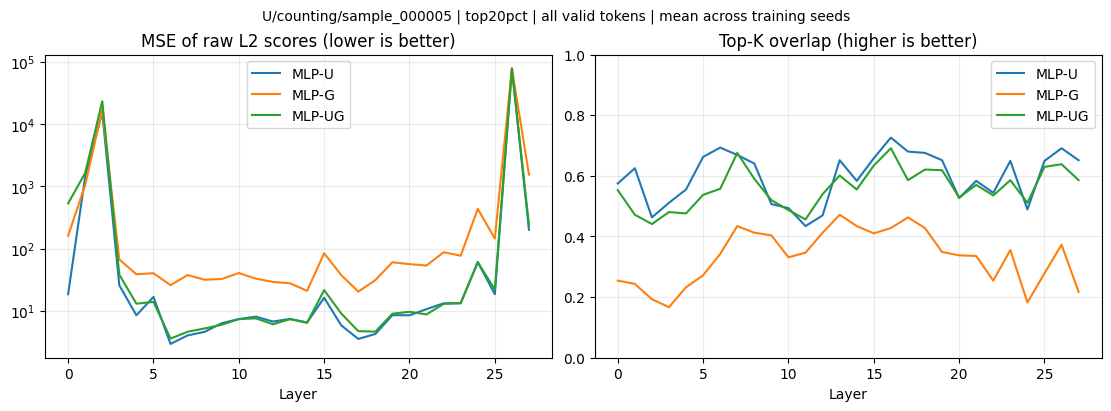

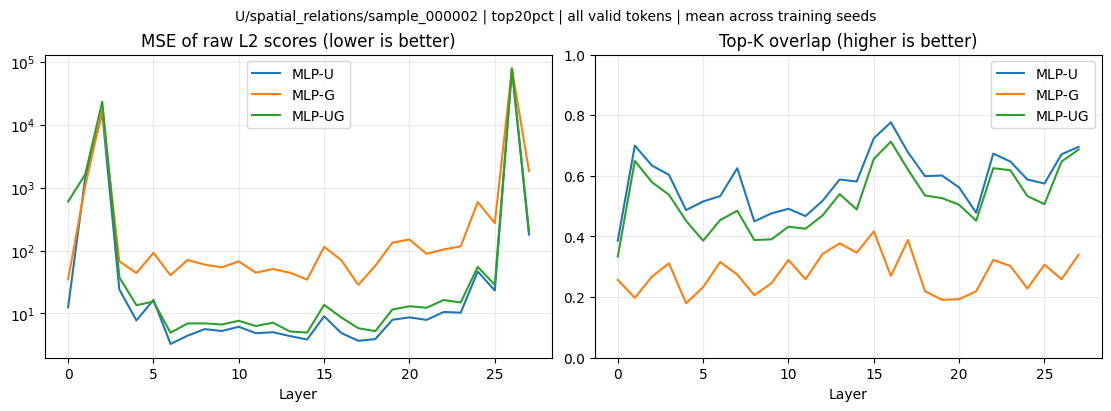

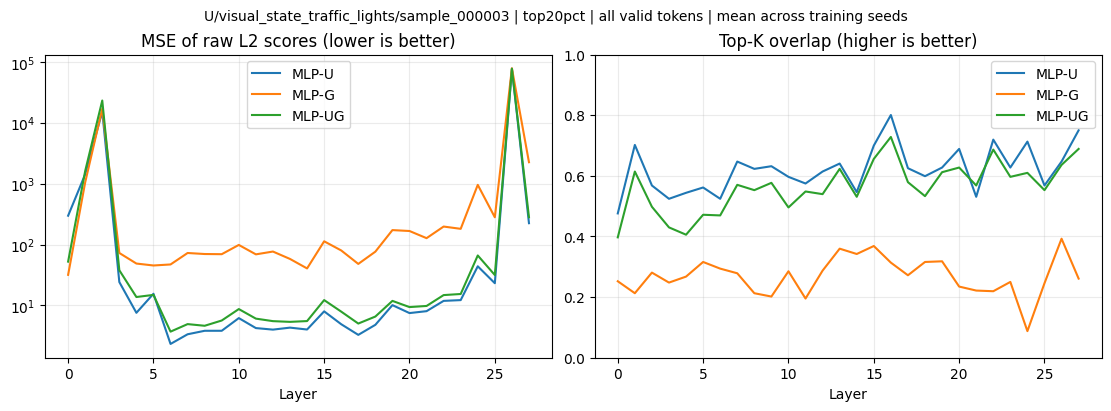

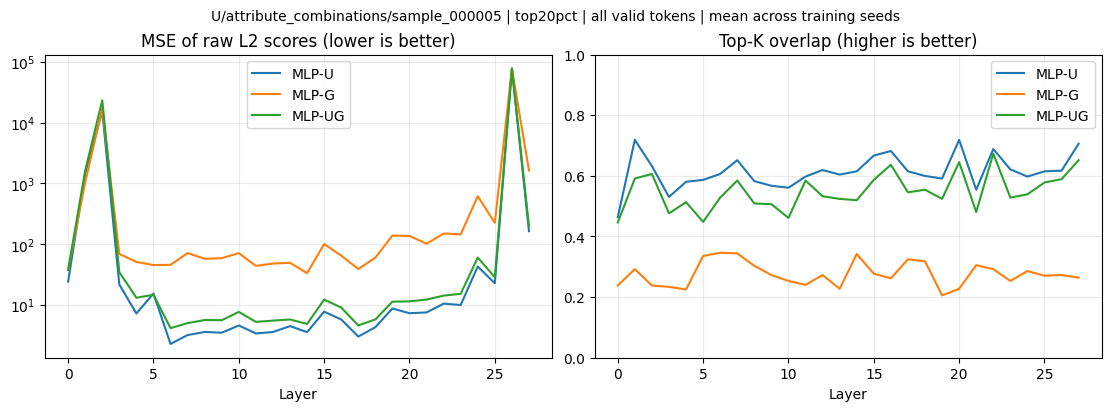

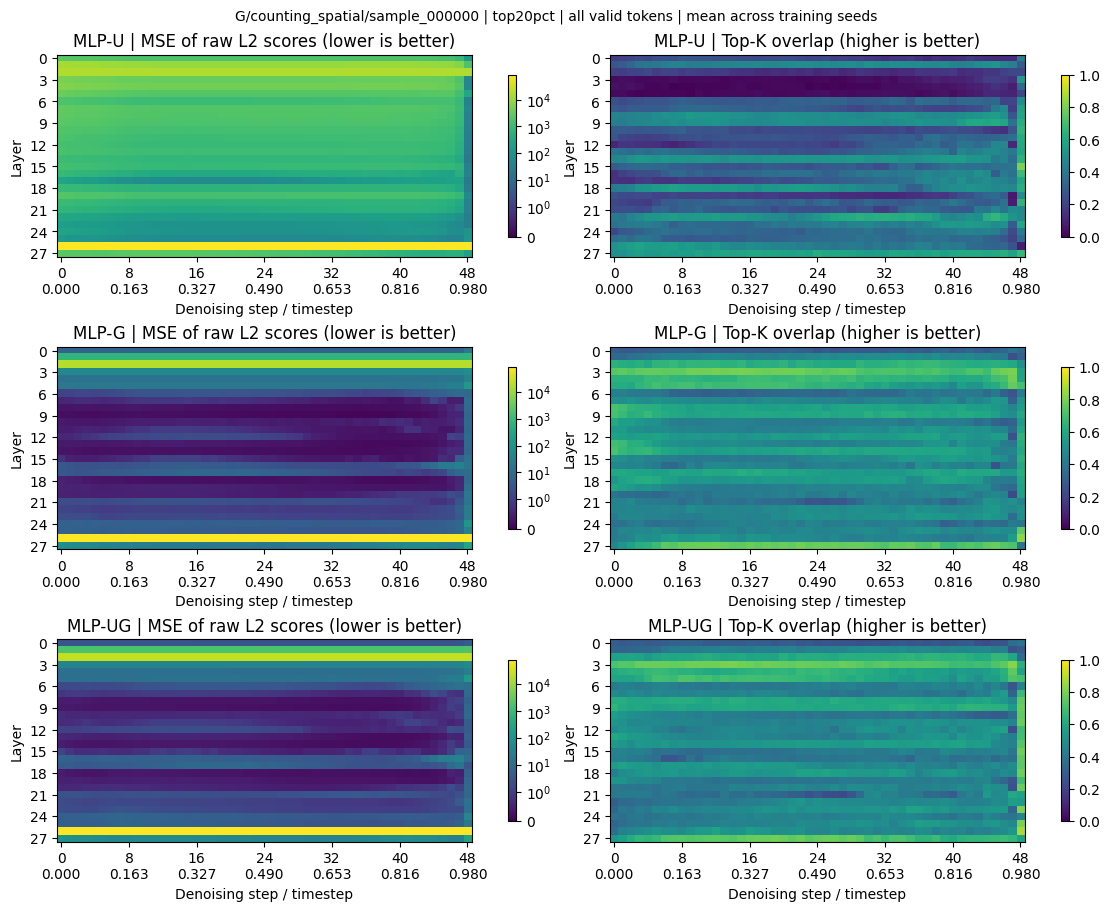

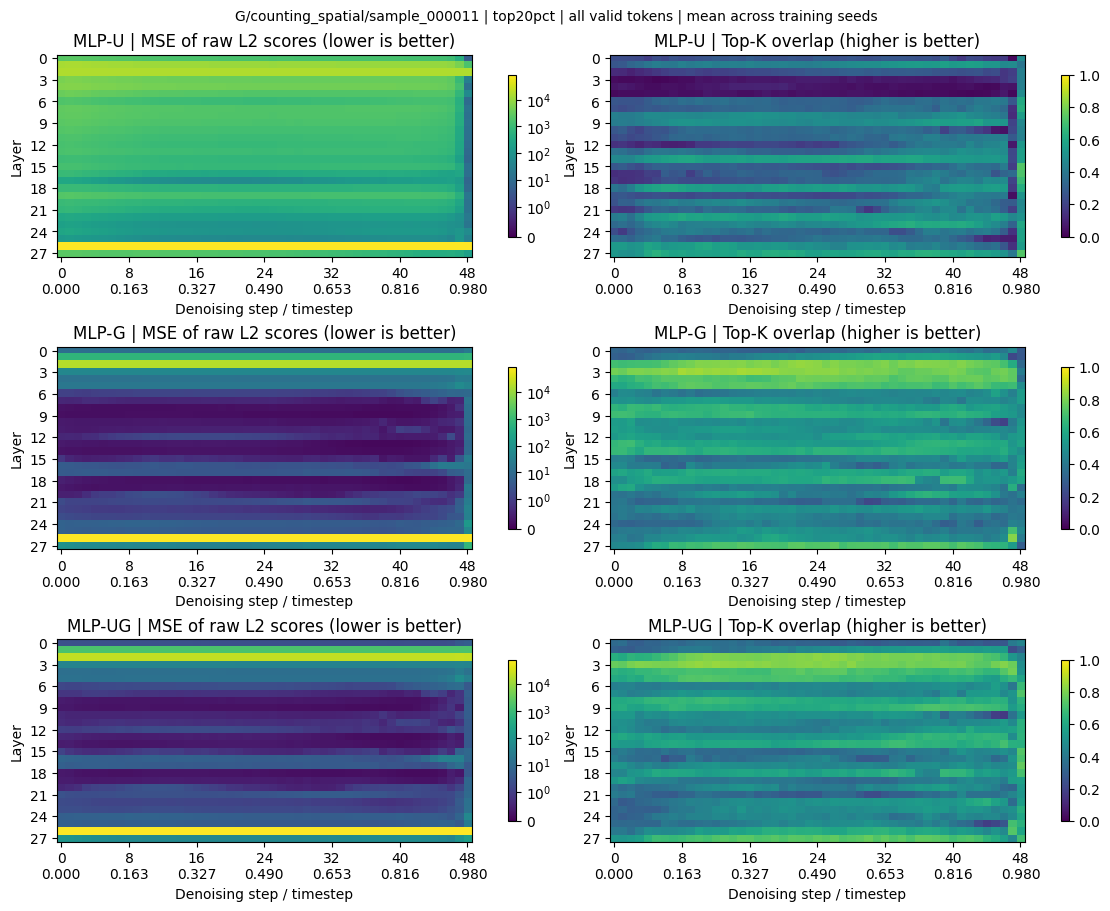

,model,seed,scope,layer,step,timestep,G_mse,G_topk_overlap,G_log_mse,G_chance_overlap,U_mse,U_topk_overlap,U_log_mse,U_chance_overlap,G_minus_U_mse,G_minus_U_topk_overlap
41160,MLP-UG,42,all,0,0,0.0000,2.0079,0.3378,0.0043,0.2003,39.3979,0.4623,0.0247,0.2005,-37.3900,-0.1245
41161,MLP-UG,42,all,0,1,0.0204,1.9972,0.3311,0.0043,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4007,-0.1312
41162,MLP-UG,42,all,0,2,0.0408,2.0045,0.3041,0.0043,0.2003,39.3979,0.4623,0.0247,0.2005,-37.3933,-0.1582
41163,MLP-UG,42,all,0,3,0.0612,1.9963,0.3074,0.0043,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4016,-0.1549
41164,MLP-UG,42,all,0,4,0.0816,1.9826,0.3209,0.0042,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4153,-0.1414
41165,MLP-UG,42,all,0,5,0.1020,1.9772,0.3074,0.0042,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4206,-0.1549
41166,MLP-UG,42,all,0,6,0.1224,1.9537,0.3378,0.0040,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4442,-0.1245
41167,MLP-UG,42,all,0,7,0.1429,1.9637,0.3378,0.0041,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4342,-0.1245
41168,MLP-UG,42,all,0,8,0.1633,1.9769,0.3311,0.0042,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4210,-0.1312
41169,MLP-UG,42,all,0,9,0.1837,1.9725,0.3345,0.0041,0.2003,39.3979,0.4623,0.0247,0.2005,-37.4253,-0.1278


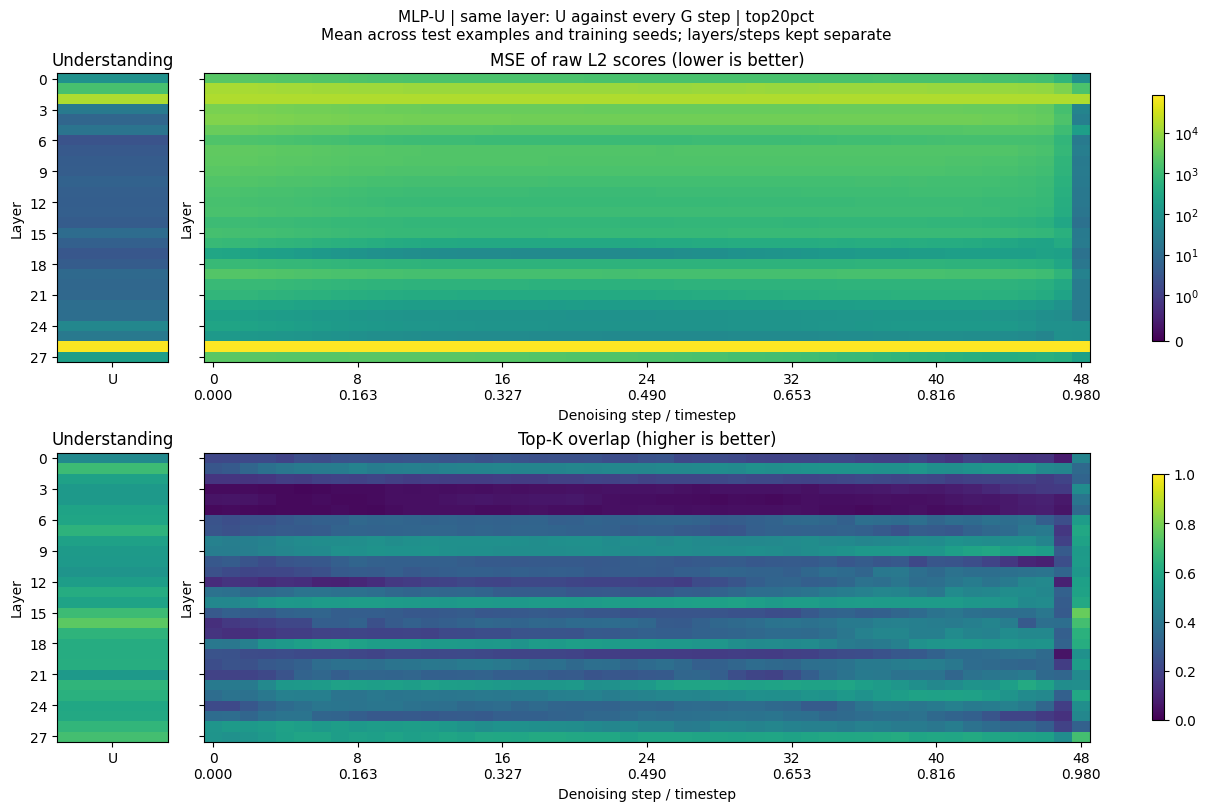

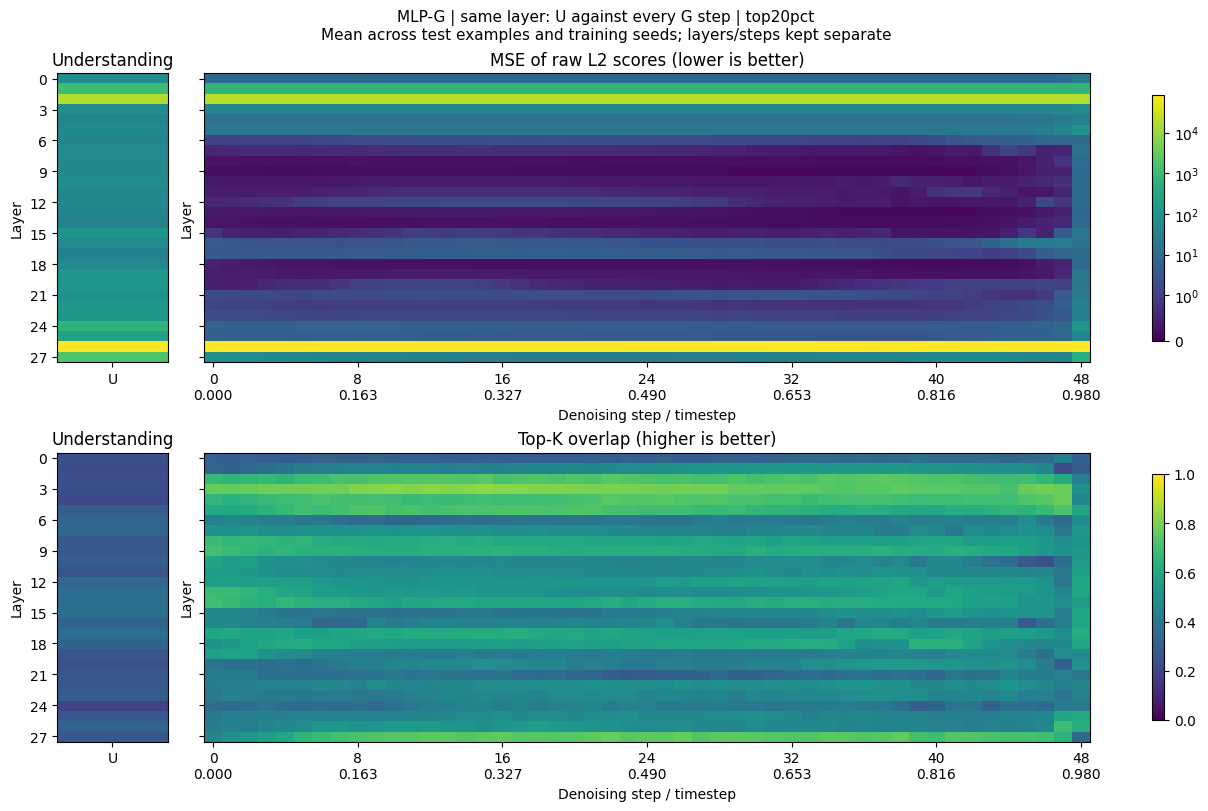

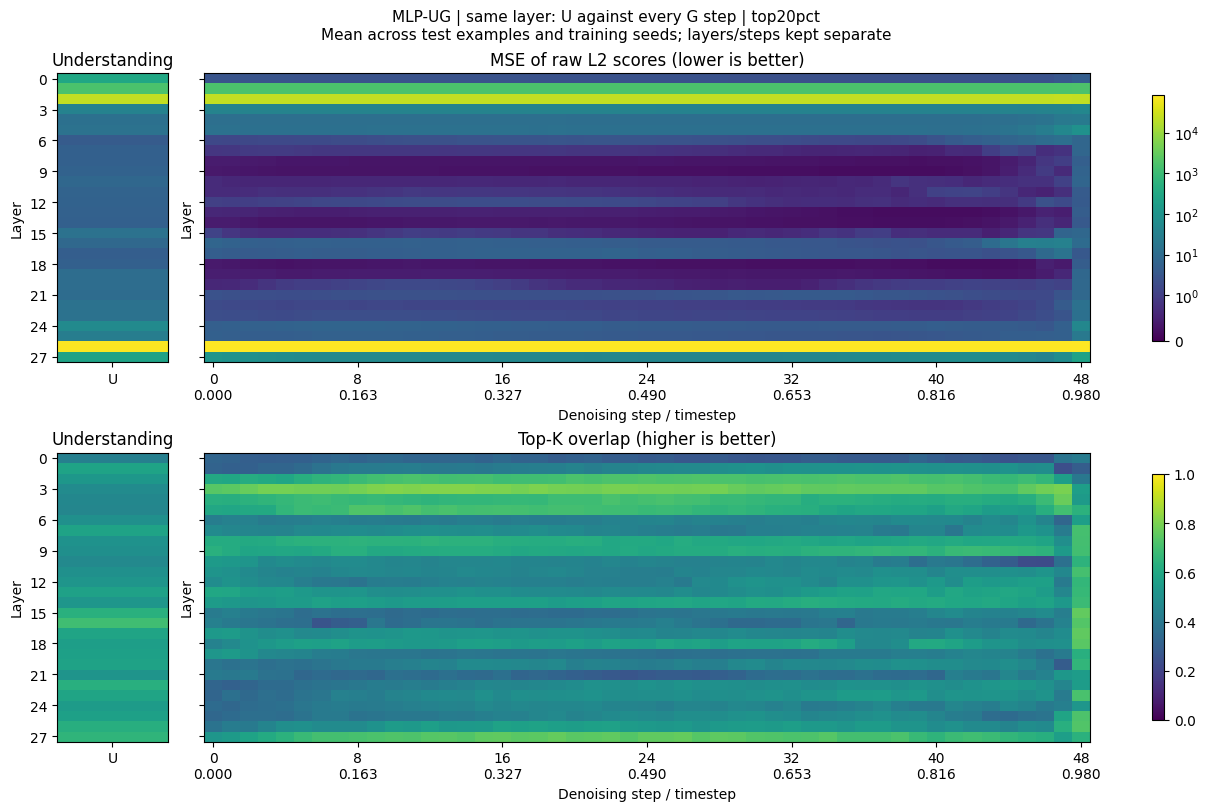

mse           topk_overlap         log_mse          \
                         mean       std         mean     std    mean     std   
model   task scope                                                             
MLP-G   G    all    3541.1282  961.8913       0.5232  0.0397  0.0051  0.0020   
        U    all    3615.5149  976.3022       0.2893  0.0298  0.1575  0.0661   
MLP-U   G    all    4900.1626  346.5744       0.3386  0.0048  1.0763  0.2203   
        U    all    3391.0228  533.0515       0.6033  0.0103  0.0098  0.0008   
MLP-UG  G    all    3777.0850  391.5560       0.5089  0.0233  0.0047  0.0010   
        U    all    3693.2431  366.2946       0.5487  0.0199  0.0124  0.0015   
Mean-G  G    all    5072.2532       NaN       0.2007     NaN  0.0225     NaN   
        U    all    5343.3542       NaN       0.1984     NaN  0.3758     NaN   
Mean-U  G    all    5408.0275       NaN       0.2007     NaN  0.3474     NaN   
        U    all    4996.3010       NaN       0.1984     NaN  0.0306     NaN   
Mean-UG G    all    5153.4542       NaN       0.2007     NaN  0.1287     NaN   
        U    all    5083.1414       NaN       0.1984     NaN  0.1080     NaN   

                   chance_overlap       
                             mean  std  
model   task scope                      
MLP-G   G    all           0.2003  0.0  
        U    all           0.2005  0.0  
MLP-U   G    all           0.2003  0.0  
        U    all           0.2005  0.0  
MLP-UG  G    all           0.2003  0.0  
        U    all           0.2005  0.0  
Mean-G  G    all           0.2003  NaN  
        U    all           0.2005  NaN  
Mean-U  G    all           0.2003  NaN  
        U    all           0.2005  NaN  
Mean-UG G    all           0.2003  NaN  
        U    all           0.2005  NaN

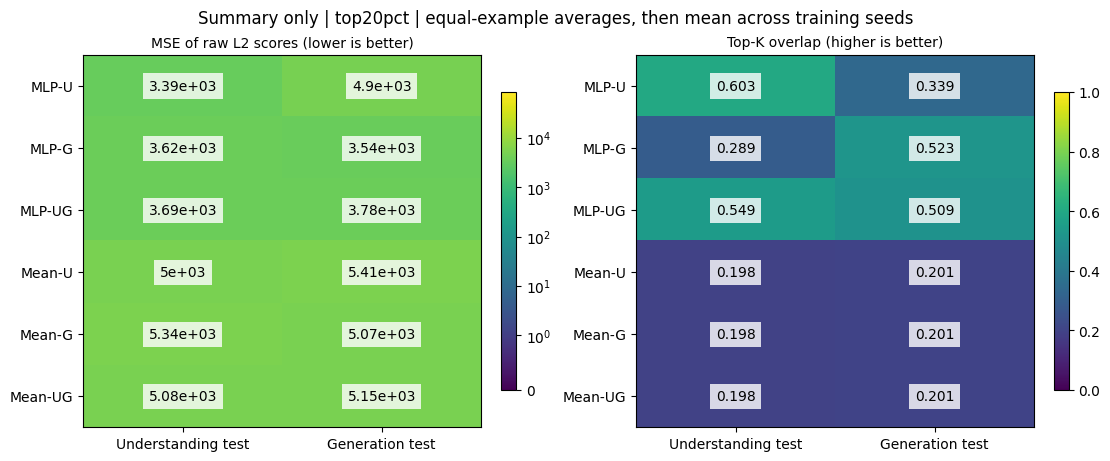

Joint-minus-specialist: positive MSE = worse; positive Top-K overlap = better.
Top-K chance overlap is K/N. Ties use independent seeded tie breaks; K=N is a trivial full selection.
Detailed results precede summaries. MSE colors use a symlog scale; saved values are raw-score MSE.
Evaluation saved to: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/evaluation_top20pct


In [ ]:
# --- 5. Evaluate each sample/layer/step first; create summaries afterwards ---
def layer_mean(tasks):
    task_means = []
    for task in tasks:
        per_example = []
        for dataset in train_pool[task]:
            labels = np.asarray(dataset.y).reshape(-1, dataset.n_layers, dataset.n_tokens)
            per_example.append(labels.mean(axis=(0, 2), dtype=np.float64))
        task_means.append(np.mean(per_example, axis=0))
    return np.log1p(np.mean(task_means, axis=0)).astype(np.float64)  # Mean raw training score, in model output units.

@torch.inference_mode()
def predict_example(model, dataset):
    predictions = np.empty(dataset.info["rows"], dtype=np.float32)
    for start in range(0, len(predictions), EVAL_BATCH_SIZE):
        indices = np.arange(start, min(start + EVAL_BATCH_SIZE, len(predictions)))
        x, layer, _ = dataset.read(indices)
        predictions[indices] = model(x.to(DEVICE), layer.to(DEVICE)).cpu().numpy()
    if not np.isfinite(predictions).all():
        raise FloatingPointError("Nonfinite test predictions")
    return np.maximum(predictions, 0)

def topk_overlap(target, prediction, key):
    n = len(target)
    k = min(n, TOP_K_COUNT) if TOP_K_COUNT is not None else max(1, int(np.ceil(TOP_K_FRACTION * n)))
    selections, cutoff_ties = [], []
    for side, values in [("target", target), ("prediction", prediction)]:
        # Independent reproducible tie breaks avoid artificial agreement between constant scores.
        rng = np.random.default_rng(int(digest([SPLIT_SEED, key, side])[:8], 16))
        selected = np.lexsort((rng.random(n), -values))[:k]
        cutoff = values[selected[-1]]
        cutoff_ties.append(bool((values > cutoff).sum() < k < (values >= cutoff).sum()))
        selections.append(selected)
    overlap = np.intersect1d(*selections).size / k  # Intersection / K, not intersection / union.
    return dict(topk_overlap=float(overlap), k=int(k), chance_overlap=k / n, full_selection=k == n,
                target_cutoff_tied=cutoff_ties[0], prediction_cutoff_tied=cutoff_ties[1])

def score_example(dataset, prediction, model_name, seed):
    info, result = dataset.info, []
    types = np.asarray(info["token_types"])
    scopes = {"all": np.ones(len(types), dtype=bool), **{str(t): types == t for t in sorted(set(types))}}
    for step_offset, step in enumerate(info["steps"]):
        for layer_offset, layer in enumerate(info["layers"]):
            offset = (step_offset * dataset.n_layers + layer_offset) * dataset.n_tokens
            target = np.asarray(dataset.y[offset:offset + dataset.n_tokens], dtype=np.float64)
            pred = np.expm1(np.maximum(prediction[offset:offset + dataset.n_tokens].astype(np.float64), 0))
            squared_error = np.square(pred - target)
            if not np.isfinite(squared_error).all():
                raise FloatingPointError("Nonfinite raw-score MSE")
            for scope, mask in scopes.items():
                key = [info["uid"], layer, step, scope]
                result.append(dict(model=model_name, seed=seed, uid=info["uid"], task=info["task"], category=info["category"],
                    scope=scope, layer=layer, step=step, timestep=info["times"][step_offset], n_tokens=int(mask.sum()),
                    mse=float(squared_error[mask].mean()),
                    log_mse=float(np.square(np.log1p(pred[mask]) - np.log1p(target[mask])).mean()),
                    **topk_overlap(target[mask], pred[mask], key)))
    return result

def same_layer_comparison(metrics):
    # Compare predictor accuracy at U layer l with G layer l at EVERY recorded step.
    # U/G examples have different tokens; their token sets are never intersected here.
    common_scopes = set(metrics[metrics.task == "U"].scope) & set(metrics[metrics.task == "G"].scope)
    metrics = metrics[metrics.scope.isin(common_scopes)]
    keys = ["model", "seed", "scope", "layer"]
    u = metrics[metrics.task == "U"].groupby(keys)[METRIC_COLUMNS].mean().add_prefix("U_").reset_index()
    g = metrics[metrics.task == "G"].groupby(keys + ["step", "timestep"])[METRIC_COLUMNS].mean().add_prefix("G_").reset_index()
    comparison = g.merge(u, on=keys, how="left", validate="many_to_one")
    if comparison[["U_mse", "U_topk_overlap"]].isna().any().any():
        raise ValueError("Missing matching understanding layer in U/G comparison")
    for metric in ["mse", "topk_overlap"]:
        comparison[f"G_minus_U_{metric}"] = comparison[f"G_{metric}"] - comparison[f"U_{metric}"]
    return comparison

def plot_layer_steps(ax, frame, metric, norm, title, step_ids, step_times):
    values = frame.pivot(index="layer", columns="step", values=metric).reindex(index=LAYER_IDS, columns=step_ids)
    image = ax.imshow(values.to_numpy(), origin="upper", aspect="auto", cmap="viridis", norm=norm)
    ticks = np.unique(np.linspace(0, len(step_ids) - 1, min(7, len(step_ids))).round().astype(int))
    ax.set_xticks(ticks, [f"{step_ids[i]}\n{step_times[i]:.3f}" for i in ticks])
    layer_ticks = np.unique(np.linspace(0, len(LAYER_IDS) - 1, min(10, len(LAYER_IDS))).round().astype(int))
    ax.set_yticks(layer_ticks, [LAYER_IDS[i] for i in layer_ticks])
    ax.set(xlabel="Denoising step / timestep", ylabel="Layer", title=title)
    return image

if TOP_K_COUNT is not None:
    if not isinstance(TOP_K_COUNT, int) or isinstance(TOP_K_COUNT, bool) or TOP_K_COUNT < 1:
        raise ValueError("TOP_K_COUNT must be a positive integer or None")
    budget_name = f"k{TOP_K_COUNT}"
else:
    if not 0 < TOP_K_FRACTION <= 1:
        raise ValueError("TOP_K_FRACTION must be in (0, 1]")
    budget_name = f"top{100 * TOP_K_FRACTION:g}pct"
EVAL_DIR = OUTPUT_DIR / f"evaluation_{budget_name}"
EVAL_DIR.mkdir(parents=True, exist_ok=True)
print(f"Selection budget: {budget_name}. Overlap is the measured agreement, not this budget.")
METRIC_COLUMNS = ["mse", "topk_overlap", "log_mse", "chance_overlap"]
save_json(EVAL_DIR / "evaluation_settings.json", dict(top_k_count=TOP_K_COUNT, top_k_fraction=TOP_K_FRACTION,
    mse="mean((predicted_raw_L2 - target_raw_L2)**2) across tokens in one sample/layer/step/scope",
    topk="intersection(predicted_topk, target_topk) / k; k=ceil(fraction*N) or min(fixed_count,N)",
    tie_policy="independent seeded random tie breaks for target/prediction; shared across models and training seeds",
    tie_seed=SPLIT_SEED, baseline="training-only mean raw L2 by layer, example/task balanced",
    comparison="U and G predictor metrics at identical layer IDs, at all G steps; no cross-task token-ID matching",
    order="per-example layer/step results first; equal-example averages; layers/steps averaged only in summaries"))

# --- A. Score all valid test tokens separately within each sample/layer/step ---
test_pool = [d for d in datasets if d.info["split"] == "test"]
rows = []
for name, tasks in MODELS.items():
    baseline = layer_mean(tasks)
    for dataset in test_pool:
        prediction = np.tile(np.repeat(baseline, dataset.n_tokens), len(dataset.info["steps"]))
        rows.extend(score_example(dataset, prediction, name.replace("MLP", "Mean"), -1))
    for seed in TRAIN_SEEDS:
        checkpoint = torch.load(OUTPUT_DIR / f"{name}_seed_{seed}.pt", map_location="cpu", weights_only=True)
        model = TokenMLP().to(DEVICE)
        model.load_state_dict(checkpoint["state_dict"])
        model.eval()
        for dataset in test_pool:
            rows.extend(score_example(dataset, predict_example(model, dataset), name, seed))
        print(f"Evaluated {name}, seed {seed}, on all U/G test tokens", flush=True)
metrics = pd.DataFrame(rows).sort_values(["task", "uid", "model", "seed", "layer", "step", "scope"])
metrics.to_csv(EVAL_DIR / "test_by_sample_layer_step_type.csv", index=False)
for task in ["U", "G"]:
    detail = metrics[metrics.task == task]
    detail.to_csv(EVAL_DIR / f"{task}_per_sample_layer_step.csv", index=False)
    print(f"{task}: {len(detail)} detailed rows saved; preview (no layer/step averaging):")
    display(detail[(detail.scope == "all") & (detail.model == "MLP-UG")].head(12).round(4))

# --- B. Per-example figures preserve all layers and generation steps (mean over training seeds only) ---
from matplotlib.colors import Normalize, SymLogNorm
max_mse = max(float(metrics[metrics.scope == "all"].mse.max()), 1.)
NORMS = {"mse": SymLogNorm(linthresh=1., vmin=0, vmax=max_mse), "topk_overlap": Normalize(0, 1)}
TITLES = {"mse": "MSE of raw L2 scores (lower is better)", "topk_overlap": "Top-K overlap (higher is better)"}
mlp_detail = metrics[(metrics.scope == "all") & metrics.model.isin(MODELS)]
for dataset in test_pool:
    info = dataset.info
    frame = mlp_detail[mlp_detail.uid == info["uid"]].groupby(["model", "layer", "step"])[METRIC_COLUMNS].mean().reset_index()
    if info["task"] == "U":
        fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
        for ax, metric in zip(axes, ["mse", "topk_overlap"]):
            for name in MODELS:
                line = frame[frame.model == name].sort_values("layer")
                ax.plot(line.layer, line[metric], label=name)
            ax.set(xlabel="Layer", title=TITLES[metric]); ax.legend(); ax.grid(alpha=.25)
            if metric == "mse":
                ax.set_yscale("symlog", linthresh=1.)
            else:
                ax.set_ylim(0, 1)
    else:
        fig, axes = plt.subplots(len(MODELS), 2, figsize=(11, 3 * len(MODELS)), constrained_layout=True, squeeze=False)
        for row, name in enumerate(MODELS):
            for col, metric in enumerate(["mse", "topk_overlap"]):
                image = plot_layer_steps(axes[row, col], frame[frame.model == name], metric, NORMS[metric],
                                         f"{name} | {TITLES[metric]}", info["steps"], info["times"])
                fig.colorbar(image, ax=axes[row, col], shrink=.8)
    fig.suptitle(f"{info['uid']} | {budget_name} | all valid tokens | mean across training seeds", fontsize=10)
    fig.savefig(EVAL_DIR / ("detail_" + info["uid"].replace("/", "_") + ".png"), dpi=160)
    plt.show(); plt.close(fig)

# --- C. Same-layer U/G comparison: average examples, but retain every layer and step ---
aligned = same_layer_comparison(metrics)
aligned.to_csv(EVAL_DIR / "U_vs_G_same_layer_every_step.csv", index=False)
display(aligned[(aligned.scope == "all") & (aligned.model == "MLP-UG")].head(12).round(4))
for name in MODELS:
    frame = aligned[(aligned.model == name) & (aligned.scope == "all")].groupby(["layer", "step", "timestep"]).mean(numeric_only=True).reset_index()
    times = frame[["step", "timestep"]].drop_duplicates().sort_values("step")
    if times.step.duplicated().any():
        raise ValueError("Generation timestep schedules differ between samples; compare consistent schedules")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={"width_ratios": [1, 8]}, sharey="row", constrained_layout=True)
    for row, metric in enumerate(["mse", "topk_overlap"]):
        u = frame[["layer", f"U_{metric}"]].drop_duplicates().set_index("layer").reindex(LAYER_IDS)
        axes[row, 0].imshow(u.to_numpy(), aspect="auto", norm=NORMS[metric], cmap="viridis")
        axes[row, 0].set_xticks([0], ["U"])
        axes[row, 0].set(ylabel="Layer", title="Understanding")
        image = plot_layer_steps(axes[row, 1], frame, f"G_{metric}", NORMS[metric], TITLES[metric], times.step.tolist(), times.timestep.tolist())
        fig.colorbar(image, ax=list(axes[row]), shrink=.85)
    fig.suptitle(f"{name} | same layer: U against every G step | {budget_name}\nMean across test examples and training seeds; layers/steps kept separate", fontsize=11)
    fig.savefig(EVAL_DIR / f"same_layer_U_vs_G_{name}.png", dpi=160)
    plt.show(); plt.close(fig)

# --- D. Summaries only after the detailed results and aligned comparisons ---
per_example = metrics.groupby(["model", "seed", "task", "category", "uid", "scope"], as_index=False)[METRIC_COLUMNS].mean()
per_seed = per_example.groupby(["model", "seed", "task", "scope"], as_index=False)[METRIC_COLUMNS].mean()
per_example.to_csv(EVAL_DIR / "summary_by_example.csv", index=False)
per_seed.to_csv(EVAL_DIR / "summary_by_seed.csv", index=False)
summary = per_seed.groupby(["model", "task", "scope"])[METRIC_COLUMNS].agg(["mean", "std"])
summary.to_csv(EVAL_DIR / "summary.csv")
display(summary.loc[(slice(None), slice(None), "all"), :].round(4))
order = ["MLP-U", "MLP-G", "MLP-UG", "Mean-U", "Mean-G", "Mean-UG"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, metric in zip(axes, ["mse", "topk_overlap"]):
    table = per_seed[per_seed.scope == "all"].groupby(["model", "task"])[metric].mean().unstack().reindex(index=order, columns=["U", "G"])
    values = table.to_numpy()
    image = ax.imshow(values, aspect="auto", cmap="viridis", norm=NORMS[metric])
    ax.set_xticks([0, 1], ["Understanding test", "Generation test"]); ax.set_yticks(range(len(order)), order)
    ax.set_title(TITLES[metric], fontsize=10)
    for (row, col), value in np.ndenumerate(values):
        ax.text(col, row, f"{value:.3g}", ha="center", va="center", bbox=dict(facecolor="white", alpha=.8, edgecolor="none"))
    fig.colorbar(image, ax=ax, shrink=.8)
fig.suptitle(f"Summary only | {budget_name} | equal-example averages, then mean across training seeds")
fig.savefig(EVAL_DIR / "summary_model_comparison.png", dpi=180)
plt.show(); plt.close(fig)

paired = mlp_detail.pivot(index=["seed", "task", "uid", "layer", "step"], columns="model", values=["mse", "topk_overlap"])
deltas = pd.DataFrame(index=paired.index)
for metric in ["mse", "topk_overlap"]:
    specialist = np.where(paired.index.get_level_values("task") == "U", paired[(metric, "MLP-U")], paired[(metric, "MLP-G")])
    deltas[f"joint_minus_specialist_{metric}"] = paired[(metric, "MLP-UG")] - specialist
deltas.reset_index().to_csv(EVAL_DIR / "joint_vs_specialist_per_sample_layer_step.csv", index=False)
print("Joint-minus-specialist: positive MSE = worse; positive Top-K overlap = better.")
print("Top-K chance overlap is K/N. Ties use independent seeded tie breaks; K=N is a trivial full selection.")
print("Detailed results precede summaries. MSE colors use a symlog scale; saved values are raw-score MSE.")
print("Evaluation saved to:", EVAL_DIR)


In [19]:
# =========================================================
# Direct MLP-U vs MLP-G overlap using ALL valid tokens
# =========================================================

from pathlib import Path
from matplotlib.colors import TwoSlopeNorm
import hashlib
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# Correct saved-run directory
CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/intership/token_mlp_results/"
    "pilot_20260911_153746"
)

EVAL_DIR = CHECKPOINT_DIR / "evaluation_top20pct"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

test_pool = [
    dataset for dataset in datasets
    if dataset.info["split"] == "test"
]

assert test_pool, "No test datasets were found."


In [20]:


# ---------------------------------------------------------
# Reproducible direct Top-K overlap
# ---------------------------------------------------------

def direct_topk_overlap(scores_u, scores_g, key):
    scores_u = np.asarray(scores_u)
    scores_g = np.asarray(scores_g)

    n = len(scores_u)

    if TOP_K_COUNT is not None:
        k = min(n, TOP_K_COUNT)
    else:
        k = max(1, int(np.ceil(TOP_K_FRACTION * n)))

    def select_topk(values, side):
        text = repr([SPLIT_SEED, key, side])
        seed = int(
            hashlib.sha256(text.encode()).hexdigest()[:8],
            16
        )
        rng = np.random.default_rng(seed)

        # Random values only break exact score ties
        return np.lexsort(
            (rng.random(n), -values)
        )[:k]

    selected_u = select_topk(scores_u, "MLP-U")
    selected_g = select_topk(scores_g, "MLP-G")

    overlap = (
        np.intersect1d(selected_u, selected_g).size / k
    )

    return overlap, k, k / n


@torch.inference_mode()
def predict_example(model, dataset):
    predictions = np.empty(dataset.info["rows"], dtype=np.float32)
    for start in range(0, len(predictions), EVAL_BATCH_SIZE):
        indices = np.arange(start, min(start + EVAL_BATCH_SIZE, len(predictions)))
        x, layer, _ = dataset.read(indices)
        predictions[indices] = model(x.to(DEVICE), layer.to(DEVICE)).cpu().numpy()
    if not np.isfinite(predictions).all():
        raise FloatingPointError("Nonfinite test predictions")
    return np.maximum(predictions, 0)



In [21]:


# ---------------------------------------------------------
# 1. Predict every test token with MLP-U and MLP-G
# ---------------------------------------------------------

predictions = {}

for model_name in ["MLP-U", "MLP-G"]:
    for seed in TRAIN_SEEDS:

        checkpoint_path = (
            CHECKPOINT_DIR /
            f"{model_name}_seed_{seed}.pt"
        )

        print("Loading:", checkpoint_path)

        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True
        )

        model = TokenMLP().to(DEVICE)
        model.load_state_dict(checkpoint["state_dict"])
        model.eval()

        for dataset in test_pool:
            uid = dataset.info["uid"]

            predictions[
                model_name,
                seed,
                uid
            ] = predict_example(model, dataset)

        print(f"Finished: {model_name}, seed={seed}")

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()



Loading: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/MLP-U_seed_42.pt
Finished: MLP-U, seed=42
Loading: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/MLP-U_seed_43.pt
Finished: MLP-U, seed=43
Loading: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/MLP-U_seed_44.pt
Finished: MLP-U, seed=44
Loading: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/MLP-G_seed_42.pt
Finished: MLP-G, seed=42
Loading: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/MLP-G_seed_43.pt
Finished: MLP-G, seed=43
Loading: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/MLP-G_seed_44.pt
Finished: MLP-G, seed=44


In [22]:

# ---------------------------------------------------------
# 2. Calculate MLP-U versus MLP-G overlap
# ---------------------------------------------------------

rows = []

for dataset in test_pool:
    info = dataset.info
    uid = info["uid"]

    for step_offset, step in enumerate(info["steps"]):
        for layer_offset, layer in enumerate(info["layers"]):

            start = (
                step_offset * dataset.n_layers
                + layer_offset
            ) * dataset.n_tokens

            end = start + dataset.n_tokens

            # Compare all U-seed/G-seed combinations
            for seed_u in TRAIN_SEEDS:
                for seed_g in TRAIN_SEEDS:

                    scores_u = predictions[
                        "MLP-U", seed_u, uid
                    ][start:end]

                    scores_g = predictions[
                        "MLP-G", seed_g, uid
                    ][start:end]

                    overlap, k, chance = direct_topk_overlap(
                        scores_u,
                        scores_g,
                        [
                            uid,
                            layer,
                            step,
                            seed_u,
                            seed_g
                        ]
                    )

                    rows.append({
                        "task": info["task"],
                        "uid": uid,
                        "layer": layer,
                        "step": step,
                        "seed_u": seed_u,
                        "seed_g": seed_g,
                        "n_tokens": dataset.n_tokens,
                        "k": k,
                        "overlap": overlap,
                        "chance": chance
                    })


direct_overlap = pd.DataFrame(rows)

direct_overlap.to_csv(
    EVAL_DIR / "direct_MLP_U_vs_G_all_tokens.csv",
    index=False
)

by_layer_step = (
    direct_overlap
    .groupby(
        ["task", "layer", "step"],
        as_index=False
    )
    .agg(
        overlap=("overlap", "mean"),
        chance=("chance", "mean")
    )
)

by_layer_step.to_csv(
    EVAL_DIR /
    "direct_MLP_U_vs_G_all_tokens_by_layer_step.csv",
    index=False
)


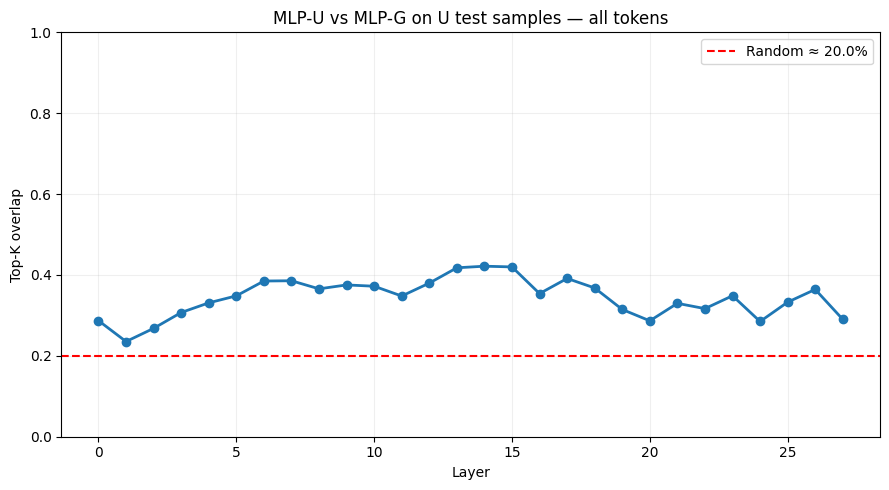

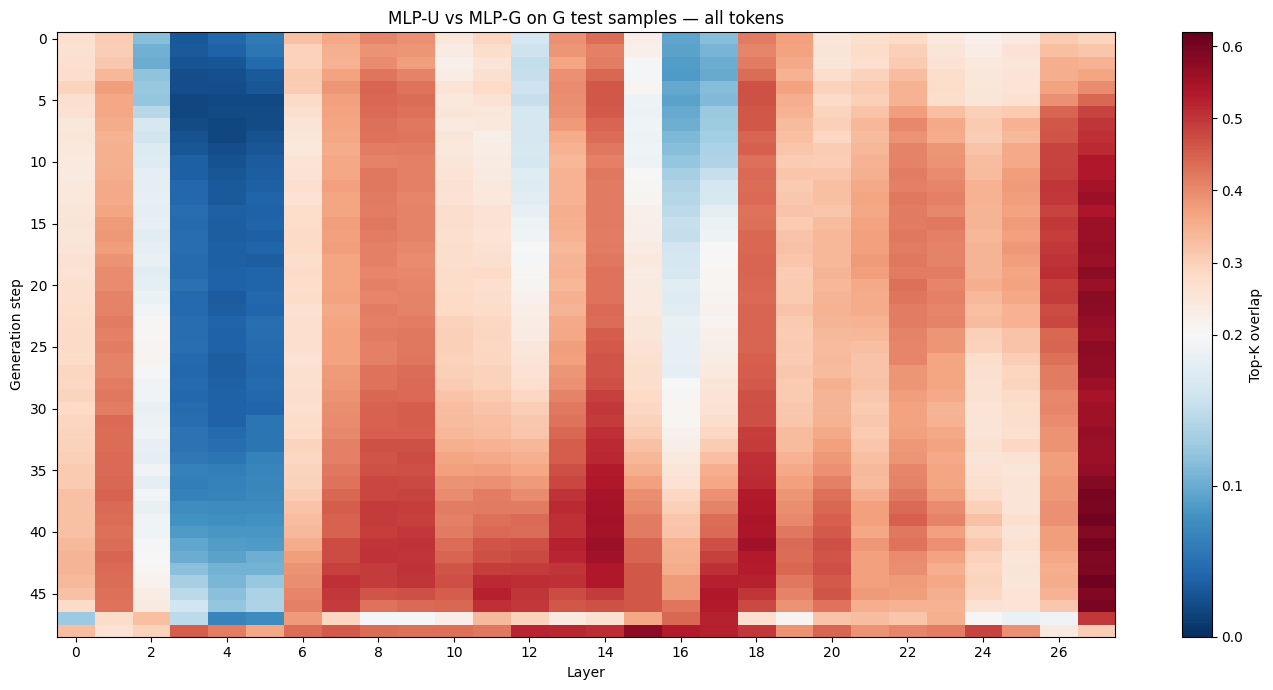

Results saved to: /content/drive/MyDrive/intership/token_mlp_results/pilot_20260911_153746/evaluation_top20pct


In [23]:


# =========================================================
# GRAPH 1: U inputs — overlap by layer
# =========================================================

u_plot = (
    by_layer_step[
        by_layer_step["task"] == "U"
    ]
    .groupby("layer", as_index=False)
    .agg(
        overlap=("overlap", "mean"),
        chance=("chance", "mean")
    )
)

chance_u = u_plot["chance"].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    u_plot["layer"],
    u_plot["overlap"],
    marker="o",
    linewidth=2
)

plt.axhline(
    chance_u,
    color="red",
    linestyle="--",
    label=f"Random ≈ {chance_u:.1%}"
)

plt.title(
    "MLP-U vs MLP-G on U test samples — all tokens"
)
plt.xlabel("Layer")
plt.ylabel("Top-K overlap")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()

plt.savefig(
    EVAL_DIR / "direct_overlap_U_all_tokens.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# GRAPH 2: G inputs — overlap by layer and step
# =========================================================

g_data = by_layer_step[
    by_layer_step["task"] == "G"
].copy()

g_map = g_data.pivot(
    index="step",
    columns="layer",
    values="overlap"
)

chance_g = g_data["chance"].mean()

vmax = max(
    0.60,
    float(np.nanmax(g_map.values)) + 0.01
)

fig, ax = plt.subplots(figsize=(14, 7))

image = ax.imshow(
    g_map.values,
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=0,
        vcenter=chance_g,
        vmax=vmax
    )
)

# Reduce tick-label clutter
x_ticks = np.arange(0, len(g_map.columns), 2)
y_ticks = np.arange(0, len(g_map.index), 5)

ax.set_xticks(
    x_ticks,
    [g_map.columns[i] for i in x_ticks]
)

ax.set_yticks(
    y_ticks,
    [g_map.index[i] for i in y_ticks]
)

ax.set_title(
    "MLP-U vs MLP-G on G test samples — all tokens"
)
ax.set_xlabel("Layer")
ax.set_ylabel("Generation step")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Top-K overlap")

plt.tight_layout()

plt.savefig(
    EVAL_DIR / "direct_overlap_G_all_tokens.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Results saved to:", EVAL_DIR)

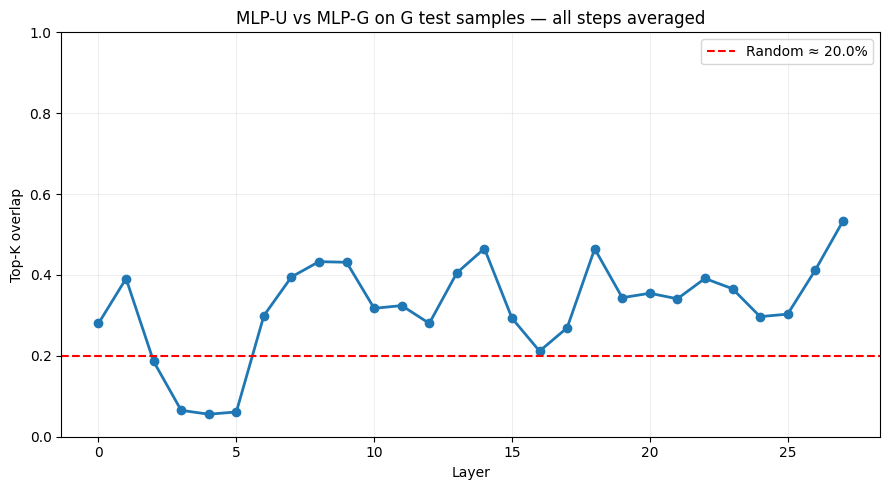

In [24]:
g_plot = (
    by_layer_step[by_layer_step["task"] == "G"]
    .groupby("layer", as_index=False)
    .agg(
        overlap=("overlap", "mean"),
        chance=("chance", "mean")
    )
)

chance_g = g_plot["chance"].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    g_plot["layer"],
    g_plot["overlap"],
    marker="o",
    linewidth=2
)

plt.axhline(
    chance_g,
    color="red",
    linestyle="--",
    label=f"Random ≈ {chance_g:.1%}"
)

plt.title("MLP-U vs MLP-G on G test samples — all steps averaged")
plt.xlabel("Layer")
plt.ylabel("Top-K overlap")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

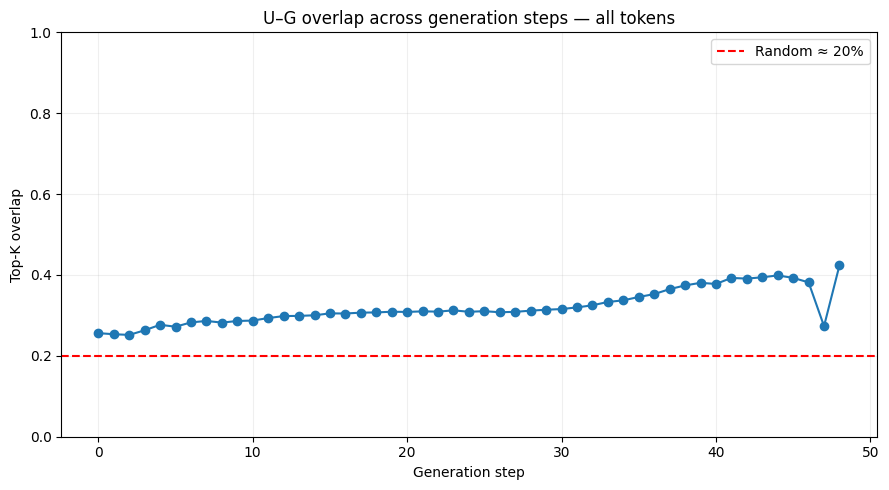

In [25]:
g_by_step = (
    by_layer_step[by_layer_step["task"] == "G"]
    .groupby("step", as_index=False)
    .agg(
        overlap=("overlap", "mean"),
        chance=("chance", "mean")
    )
)

plt.figure(figsize=(9, 5))

plt.plot(
    g_by_step["step"],
    g_by_step["overlap"],
    marker="o"
)

plt.axhline(
    g_by_step["chance"].mean(),
    color="red",
    linestyle="--",
    label="Random ≈ 20%"
)

plt.title("U–G overlap across generation steps — all tokens")
plt.xlabel("Generation step")
plt.ylabel("Top-K overlap")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()